# 03 - Training - Classical ML model (XGBoost)

Section **3.4 Training - Classical ML model** of the report.

## Brief

Classical ML model: justify the choice of algorithm and describe hyperparameters and the tuning process.

- Justify the algorithm choice (XGBoost or other).
- Initial hyperparameters and tuning process (grid / random / bayes).
- Validation strategy (CV, holdout).
- Persist the trained model to `models/` and metrics to `reports/`.

In [ ]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import wandb
from dotenv import load_dotenv
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

from diplo_mod_1.constants import CONFIGS, MODELS, PROCESSED, RANDOM_STATE, REPORTS
from diplo_mod_1.domain.evaluate import evaluate_predictor
from diplo_mod_1.training import XGBoostTuner, XGBoostTuningConfig

load_dotenv()  # reads WANDB_API_KEY / WANDB_ENABLED from ../.env, if present
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Experiment tracking is opt-in: set WANDB_ENABLED=true (in .env or the shell)
# to log this run to Weights & Biases. Off by default so `poe check` / nbmake
# executions don't create a W&B run on every lint/test pass.
WANDB_ENABLED = os.environ.get("WANDB_ENABLED", "false").lower() == "true"

## Step 1 — Load processed dataset

Unscaled tabular features exported by notebook 02 (`data/processed/xgboost/`).

In [2]:
xgb_dir = PROCESSED / "xgboost"
X_train = np.load(xgb_dir / "X_train.npy")
X_val = np.load(xgb_dir / "X_val.npy")
X_test = np.load(xgb_dir / "X_test.npy")
y_train = np.load(xgb_dir / "y_train.npy")
y_val = np.load(xgb_dir / "y_val.npy")
y_test = np.load(xgb_dir / "y_test.npy")

feature_meta = json.loads((xgb_dir / "feature_names.json").read_text(encoding="utf-8"))
feature_names = feature_meta["feature_names"]

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")

X_train: (83180, 40), X_val: (20796, 40), X_test: (25995, 40)
Features: 40


## Step 2 — Baseline model

**Algorithm choice: XGBoost.** Gradient-boosted trees handle the mix of continuous, binary, and target-encoded features here without scaling, capture non-linear effects noted in EDA (e.g. the vintage-year U-shape), and are the standard strong baseline for tabular regression — a better fit than a linear model given the feature set built in notebook 02.

Untuned defaults first, to have a number the tuned model must beat.

In [ ]:
tuning_config_name = os.environ.get("XGBOOST_TUNING_CONFIG", "xgboost_tuning.json")
tuning_config = XGBoostTuningConfig.from_json(CONFIGS / tuning_config_name)
print(f"Loaded tuning config: {tuning_config_name}")

if WANDB_ENABLED:
    run_name = os.environ.get("WANDB_RUN_NAME") or (
        f"xgboost-{Path(tuning_config_name).stem}-{tuning_config.n_trials}trials"
        f"-maxdepth{tuning_config.search_space.max_depth[1]}"
    )
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=run_name,
        group="xgboost-baseline",
        job_type="hpo",
        config={"tuning_config_name": tuning_config_name, **tuning_config.model_dump()},
    )

baseline = XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_rmse = root_mean_squared_error(y_val, baseline_pred)
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_r2 = r2_score(y_val, baseline_pred)
print(f"Baseline val RMSE: {baseline_rmse:.4f}")
print(f"Baseline val MAE:  {baseline_mae:.4f}")
print(f"Baseline val R2:   {baseline_r2:.4f}")

if WANDB_ENABLED:
    wandb.log(
        {
            "baseline_val_rmse": baseline_rmse,
            "baseline_val_mae": baseline_mae,
            "baseline_val_r2": baseline_r2,
        }
    )

## Step 3 — Hyperparameter tuning (Optuna)

Bayesian search (TPE sampler) via `XGBoostTuner` (`src/diplo_mod_1/training/`), configured from a JSON file in `configs/` — default `xgboost_tuning.json`, override with the `XGBOOST_TUNING_CONFIG` env var (e.g. `XGBOOST_TUNING_CONFIG=xgboost_tuning_wide.json`) to try a different search space without touching code or overwriting the default file. Search-space bounds: `max_depth` (capped at 8 by default — deeper trees were the main overfit driver in the first pass), `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `min_child_weight`, and regularization terms `reg_alpha`, `reg_lambda`, `gamma`. Each trial fits on `train` and scores RMSE against the held-out `val` split, with early stopping — `val` doubles as both the tuning objective and the early-stopping monitor, so `test` stays untouched until final evaluation.

In [4]:
def log_trial_to_wandb(study: optuna.Study, trial: optuna.trial.FrozenTrial) -> None:
    wandb.log({"trial": trial.number, "val_rmse": trial.value, **trial.params})


tuner = XGBoostTuner(tuning_config)
callbacks = [log_trial_to_wandb] if WANDB_ENABLED else None
study = tuner.tune(X_train, y_train, X_val, y_val, callbacks=callbacks)

print(f"Best val RMSE: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

if WANDB_ENABLED:
    wandb.log(
        {
            "best_val_rmse": study.best_value,
            **{f"best_{k}": v for k, v in study.best_params.items()},
        }
    )

  0%|          | 0/50 [00:00<?, ?it/s]

Best val RMSE: 1.6434
Best params: {'max_depth': 7, 'learning_rate': 0.0590053229998902, 'n_estimators': 977, 'subsample': 0.8311554812252515, 'colsample_bytree': 0.917482392639744, 'min_child_weight': 7, 'reg_alpha': 0.0012616393080595119, 'reg_lambda': 8.245980479107059e-07, 'gamma': 0.0005925049721311043}


## Step 4 — Final model

Refit with `study.best_params`, same early-stopping setup, to pick the boosting round that generalizes best rather than the fixed `n_estimators` from the search.

In [5]:
best_model = tuner.fit_best(X_train, y_train, X_val, y_val, study)
print(f"Best iteration: {best_model.best_iteration}")

Best iteration: 975


## Step 5 — Evaluate on train / val / test

In [6]:
splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
result = evaluate_predictor(best_model, splits, model_type="xgboost")

for m in result.metrics:
    print(f"{m.split:5s}  RMSE={m.rmse:.4f}  MAE={m.mae:.4f}  R2={m.r2:.4f}")
    if WANDB_ENABLED:
        wandb.log({f"{m.split}_rmse": m.rmse, f"{m.split}_mae": m.mae, f"{m.split}_r2": m.r2})

train  RMSE=1.2102  MAE=0.9338  R2=0.8413
val    RMSE=1.6434  MAE=1.2825  R2=0.7083
test   RMSE=1.6340  MAE=1.2711  R2=0.7118


## Step 6 — Feature importance

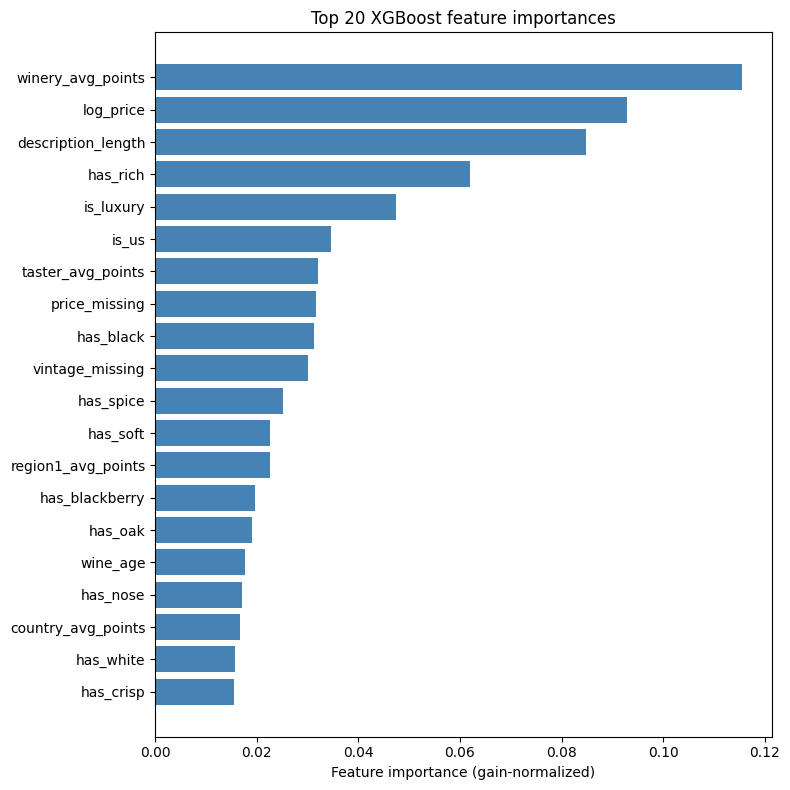

In [7]:
importances = best_model.feature_importances_
order = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color="steelblue")
ax.set_xlabel("Feature importance (gain-normalized)")
ax.set_title("Top 20 XGBoost feature importances")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"feature_importance": wandb.Image(fig)})

## Step 7 — Persist model and metrics

Model checkpoint to `models/`, metrics to `reports/` — consumed by notebook 05 for the model comparison. If `WANDB_ENABLED=true`, the same run also has the search-space config, every Optuna trial, baseline metrics, final train/val/test metrics, the feature-importance plot, and the model checkpoint itself (as a W&B artifact) logged to Weights & Biases (project from `WANDB_PROJECT`, default `diplo-mod-1`; run name from `WANDB_RUN_NAME`, default auto-generated from the tuning config — e.g. `xgboost-baseline-50trials-maxdepth8` — instead of a random fancy name).

In [8]:
MODELS.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

model_path = MODELS / "xgboost_baseline.joblib"
joblib.dump(best_model, model_path)
(REPORTS / "xgboost_metrics.json").write_text(result.model_dump_json(indent=2), encoding="utf-8")

print(f"Model saved to {model_path}")
print(f"Metrics saved to {REPORTS / 'xgboost_metrics.json'}")

if WANDB_ENABLED:
    artifact = wandb.Artifact("xgboost_baseline", type="model")
    artifact.add_file(str(model_path))
    wandb.log_artifact(artifact)
    wandb.finish()

Model saved to ..\models\xgboost_baseline.joblib
Metrics saved to ..\reports\xgboost_metrics.json


wandb: uploading history steps 31-39, summary; uploading artifact xgboost_baseline; updating run metadata


wandb: uploading history steps 31-39, summary; uploading media\images\feature_importance_55_006f9a957630858f1ed6.png; uploading output.log; uploading wandb-summary.json; uploading config.yaml


wandb: uploading history steps 31-39, summary; uploading media\images\feature_importance_55_006f9a957630858f1ed6.png; uploading output.log; uploading wandb-summary.json


wandb: uploading history steps 31-39, summary; uploading media\images\feature_importance_55_006f9a957630858f1ed6.png


...

wandb: uploading history steps 40-44, summary


wandb: uploading history steps 45-55, summary, console lines 3-10


wandb: 
wandb: Run history:
wandb:      baseline_val_mae ▁
wandb:       baseline_val_r2 ▁
wandb:     baseline_val_rmse ▁
wandb: best_colsample_bytree ▁
wandb:            best_gamma ▁
wandb:    best_learning_rate ▁
wandb:        best_max_depth ▁
wandb: best_min_child_weight ▁
wandb:     best_n_estimators ▁
wandb:        best_reg_alpha ▁
wandb:                   +22 ...
wandb: 
wandb: Run summary:
wandb:      baseline_val_mae 1.33591
wandb:       baseline_val_r2 0.68679
wandb:     baseline_val_rmse 1.70284
wandb: best_colsample_bytree 0.91748
wandb:            best_gamma 0.00059
wandb:    best_learning_rate 0.05901
wandb:        best_max_depth 7
wandb: best_min_child_weight 7
wandb:     best_n_estimators 977
wandb:        best_reg_alpha 0.00126
wandb:                   +22 ...
wandb: 


wandb:  View run xgboost-baseline-50trials-maxdepth8 at: https://wandb.ai/leonardo-a-heis/diplo-mod-1/runs/vx0254by
wandb:  View project at: https://wandb.ai/leonardo-a-heis/diplo-mod-1
wandb: Synced 5 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260728_124542-vx0254by\logs


## Design notes (report)

**Algorithm choice:** XGBoost — handles the mixed continuous/binary/target-encoded feature matrix from notebook 02 without scaling, and captures non-linear relationships (e.g. the vintage-year U-shape found in EDA) that a linear baseline cannot.

**Tuning process:** Bayesian optimization via Optuna (TPE sampler), 50 trials over 9 hyperparameters, run through the reusable `XGBoostTuner` class (`src/diplo_mod_1/training/`) rather than inline in the notebook — mirrors the `DataCleaner`/`FeatureEngineer`/`TabularEncoder` pattern from notebook 02. Each trial uses early stopping against `val` rather than a fixed boosting-round count, so the search jointly tunes regularization-style parameters and training length.

**Validation strategy:** holdout, not k-fold CV — reuses the stratified `train`/`val`/`test` split from notebook 02. `val` drives both the Optuna objective and early stopping; `test` is touched only once, for the final reported metrics (via `evaluate_predictor`, shared with notebook 04 through the `WineScorePredictor` protocol), keeping it a fair held-out estimate for the notebook 05 comparison against the neural network.

**Persistence:** trained model as `models/xgboost_baseline.joblib`; `ModelMetrics`/`EvaluationResult` (existing domain schemas) as `reports/xgboost_metrics.json`; optionally the full run (config, trials, metrics, plot, model artifact) to Weights & Biases when `WANDB_ENABLED=true`.